# Notebook 4 — SHAP Explainability

Feature importance from XGBoost tells us *global* importance. SHAP (SHapley Additive exPlanations) tells us *why* the model made each individual prediction.

We use `TreeExplainer` — exact SHAP values for tree-based models, no approximation.

In [1]:
import pandas as pd, numpy as np, shap, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()

c:\Users\ashwi\Desktop\machine_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/Instagram_Analytics.csv')

def engineer_features(df):
    df = df.copy()
    df['total_interactions']     = df['likes'] + df['comments'] + df['shares'] + df['saves']
    df['save_rate']              = df['saves']   / (df['reach'] + 1)
    df['comment_like_ratio']     = df['comments']/ (df['likes']  + 1)
    df['share_rate']             = df['shares']  / (df['reach'] + 1)
    df['impression_reach_ratio'] = df['impressions'] / (df['reach'] + 1)
    df['virality_score']         = (df['shares'] + df['saves']) / (df['reach'] + 1)
    df['engagement_depth']       = df['comments'] / (df['total_interactions'] + 1)
    df['is_weekend']   = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)
    df['is_prime_time']= df['post_hour'].between(18,22).astype(int)
    df['is_morning']   = df['post_hour'].between(6,10).astype(int)
    df['hour_sin']     = np.sin(2*np.pi*df['post_hour']/24)
    df['hour_cos']     = np.cos(2*np.pi*df['post_hour']/24)
    le = LabelEncoder()
    for col in ['media_type','content_category','traffic_source','account_type','day_of_week']:
        df[col+'_enc'] = le.fit_transform(df[col])
    return df

FULL_FEATURES = [
    'follower_count','has_call_to_action','post_hour','caption_length','hashtags_count',
    'engagement_rate','reach','impressions','likes','comments','shares','saves','followers_gained',
    'total_interactions','save_rate','comment_like_ratio','share_rate',
    'impression_reach_ratio','virality_score','engagement_depth',
    'is_weekend','is_prime_time','is_morning','hour_sin','hour_cos',
    'media_type_enc','content_category_enc','traffic_source_enc','account_type_enc','day_of_week_enc'
]

df = engineer_features(df)
df['target'] = df['performance_bucket_label'].map({'low':0,'medium':1,'high':2,'viral':3})
X, y = df[FULL_FEATURES], df['target']
_, Xte, _, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

xgb = joblib.load('../models/xgb_full.pkl')
print('Model loaded.')

Model loaded.


## TreeExplainer on 500 test samples

In [3]:
sample = Xte.sample(500, random_state=42)
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)
# shap_values shape: (n_samples, n_features, n_classes)
print(f'SHAP values shape: {shap_values.shape}')
print('Classes: 0=low, 1=medium, 2=high, 3=viral')

SHAP values shape: (500, 30, 4)
Classes: 0=low, 1=medium, 2=high, 3=viral


## Summary plot — viral class (class 3)

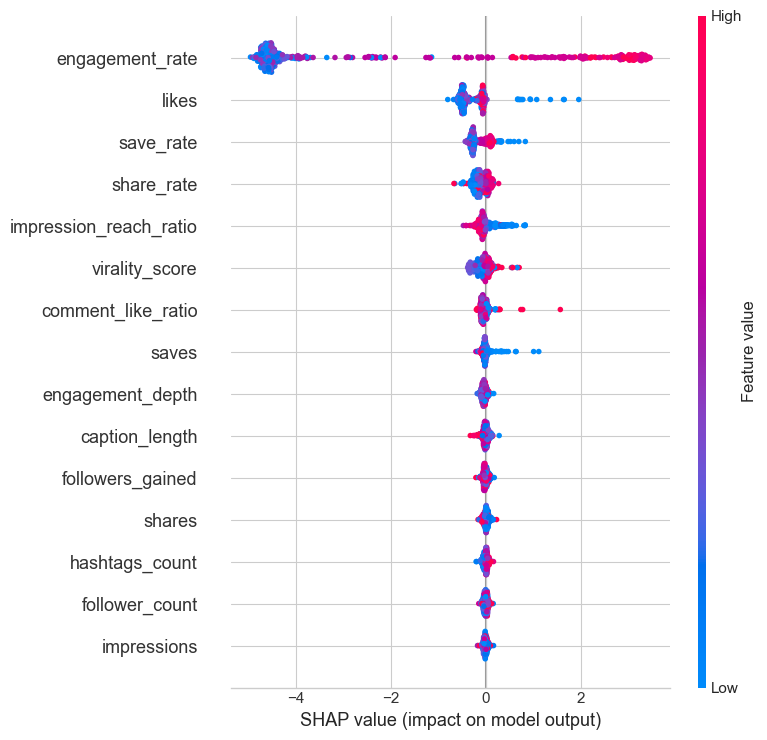

In [6]:
shap.summary_plot(shap_values[:, :, 3], sample, show=True, max_display=15,title='SHAP Summary — Viral Class')

## Bar plot — mean |SHAP| per feature (viral)

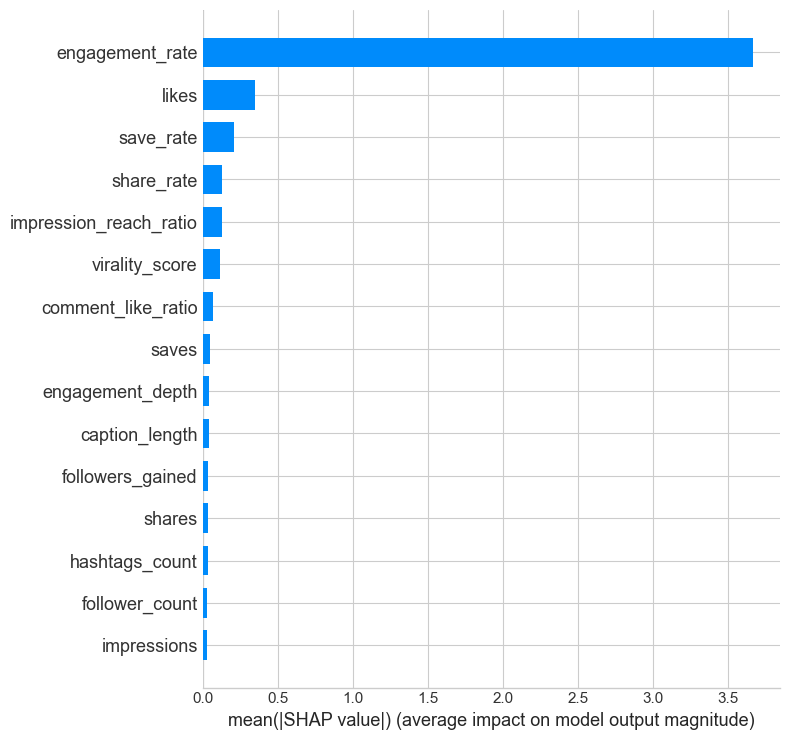

In [8]:
shap.summary_plot(shap_values[:, :, 3], sample, plot_type='bar', show=True,
                  max_display=15,title='Mean |SHAP| — Viral Class')

## Waterfall plot — single viral post explanation

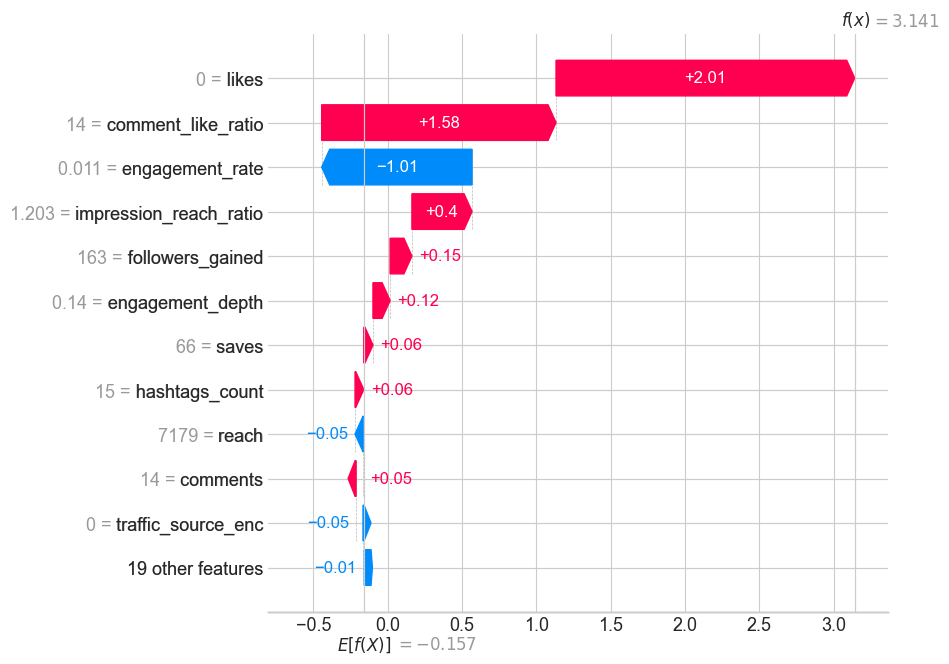

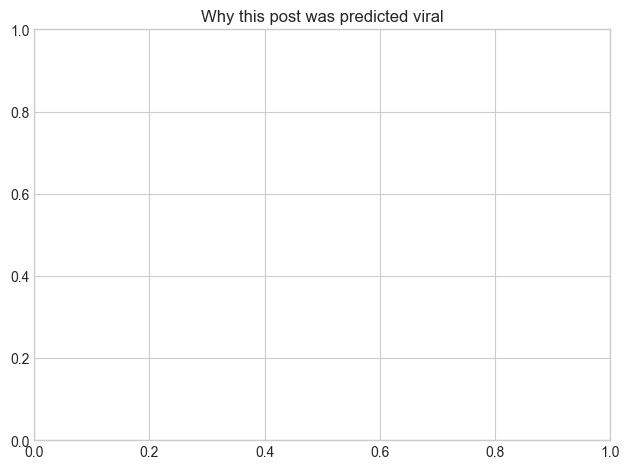

In [9]:
viral_indices = yte[yte == 3].index
sample_viral  = Xte.loc[viral_indices].head(1)
sv_single     = explainer(sample_viral)
# sv_single.values shape: (1, n_features, n_classes)
shap.waterfall_plot(shap.Explanation(
    values      = sv_single.values[0, :, 3],
    base_values = sv_single.base_values[0, 3],
    data        = sample_viral.values[0],
    feature_names = FULL_FEATURES
), max_display=12)
plt.title('Why this post was predicted viral', fontsize=12)
plt.tight_layout()
plt.show()

## Key SHAP insights

1. **`engagement_rate`** has SHAP values 10x larger than the next feature — it dominates all class predictions.
2. **`save_rate`** is the second-strongest signal for the viral class — bookmarks signal high-intent audience behaviour.
3. **`comment_like_ratio`** pushes predictions toward viral when comments are disproportionately high — controversial or discussion-generating content.
4. Metadata features (`media_type_enc`, `post_hour`) have SHAP values near zero — confirming the pre-posting model's accuracy ceiling.

This supports the core finding: **content performance is driven by how audiences respond, not by scheduling or format decisions.**